# Notebook 01: Data Collection & Literature Review
## The 15-Minute Shanghai Project — Track A: Healthy Lifestyle & Sport

**Author:** [Yixuan Qin]  
**Date:** May 2026  
**Course:** Urban Data Analysis — Graduate Project

---

## 0. Literature Review — The 15-Minute City: Measurement, Mobility, and Equity

The 15-minute city (15MC) concept, articulated by Carlos Moreno (2016) and popularised through Paris's urban policy, proposes that all essential urban needs — work, food, health, education, culture, and leisure — should be accessible within a 15-minute walk or bicycle ride from one's residence. Moreno's framework, rooted in 'chrono-urbanism', shifts urban planning from a focus on mobility speed to proximity as the organising principle of city life. It represents a departure from the modernist functional-separation paradigm toward an integrated, polycentric urban form.

Operationalising the 15MC concept for empirical analysis requires defining measurable indicators. Weng et al. (2019) proposed a walkability-based accessibility framework using POI data to assess whether Chinese urban neighbourhoods meet 15-minute community life circle (15分钟社区生活圈) standards codified in China's 2016 urban planning guidelines. Shanghai was among the first Chinese cities to adopt these guidelines as binding planning targets. Subsequent work by Wu et al. (2021) extended this to multi-modal accessibility, demonstrating that cycling dramatically expands the service catchment area compared to walking alone — a finding central to this project's dual walk/bike baseline methodology.

The linkage between built environment and public health outcomes provides the theoretical foundation for Track A. Sallis et al. (2016) established through a 14-city international study that neighborhood walkability, recreational infrastructure, and access to public transport are consistently associated with higher levels of physical activity. Frank et al. (2010) demonstrated that each additional kilometre of walkable street network is associated with a 6–8% increase in the probability of meeting weekly physical activity guidelines. These findings justify the inclusion of sport facilities, green space, and cycling infrastructure as core indicators in our healthy-lifestyle scoring layer.

However, the 15MC model has attracted robust critique. The central equity concern — articulated by Pozoukidou and Chatziyiannaki (2021) — is that the amenities enabling a 15-minute lifestyle (parks, quality food retail, fitness facilities) cluster in higher-income districts, driving gentrification and displacement. If walkable neighbourhoods are predominantly wealthy neighbourhoods, the 15MC becomes an instrument of exclusion rather than inclusion. Quinton (2022) further argues that the 15MC discourse centres the experiences of able-bodied, child-free professionals, neglecting the mobility needs of caregivers, the elderly, and people with disabilities. This project directly engages with these critiques by incorporating affordability data (Anjuke listings) alongside amenity access, enabling us to ask: *Does healthy-lifestyle access correlate with housing cost, and where are the corridors of high access AND low cost?*

Within the Shanghai context, a city of 25 million with extreme spatial inequality between the Puxi core and peripheral new towns (Lingang, Songjiang New City), the question is particularly salient. The municipal government has designated 15-minute life circles as a planning standard, but empirical assessment of whether these standards are met — and for whom — remains limited. This project fills that gap by building a fine-grained (500m grid), multi-modal accessibility index covering both universal baseline services and health/sport-specific amenities, visualised as an interactive public web tool.

**References:**
- Moreno, C. (2016). La ville du quart d'heure: pour un nouveau chrono-urbanisme.
- Weng, M. et al. (2019). The 15-minute walkable neighbourhoods: Measurement, social inequalities, and implications for building healthy communities in urban China. *Journal of Transport & Health*, 13.
- Sallis, J.F. et al. (2016). Physical activity in relation to urban environments in 14 cities worldwide: a cross-sectional study. *The Lancet*, 387(10034).
- Pozoukidou, G. & Chatziyiannaki, Z. (2021). 15-Minute City: Decomposing the new urban planning eutopia. *Sustainability*, 13(2).
- Quinton, A. (2022). The 15-minute city: A feminist critique. *Journal of Urban Affairs*.
- Frank, L.D. et al. (2010). Carbonless footprints: Promoting health and climate change mitigation through active transport. *Preventive Medicine*, 50.

> **AI Assistance Note:** Portions of this literature review were drafted with AI assistance and verified against original sources. All analytical and interpretive work in subsequent sections is the author's own.

---
## 1. Setup and Environment

In [51]:
import sys
import os
import json
import pickle
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shapely
from shapely import wkb
from shapely.geometry import Point, Polygon, box
import pyproj

warnings.filterwarnings('ignore')

# Paths
RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
OUTPUT_DIR = Path('../data/output')
DATA_SRC = Path('E:/shufen final')  # Original data location

for d in [PROCESSED_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Python {sys.version}')
print(f'GeoPandas {gpd.__version__}')
print(f'Shapely {shapely.__version__}')
print(f'PyProj {pyproj.__version__}')

# Projected CRS for Shanghai: UTM Zone 51N (EPSG:32651)
CRS_GEO = 'EPSG:4326'
CRS_PROJ = 'EPSG:32651'

Python 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
GeoPandas 1.1.2
Shapely 2.1.2
PyProj 3.7.2


---
## 2. Load Shanghai Administrative Boundaries

In [52]:
# Load district boundaries
districts_gdf = gpd.read_file(DATA_SRC / 'sh-province-district.geojson')
print(f'District features: {len(districts_gdf)}')
print(f'CRS: {districts_gdf.crs}')

# Extract Shanghai total boundary (province-level polygon)
shanghai_boundary = districts_gdf[districts_gdf['level'] == 'province'].copy()
shanghai_districts = districts_gdf[districts_gdf['level'] == 'district'].copy()

print(f'\nShanghai boundary (province): {len(shanghai_boundary)}')
print(f'Districts: {len(shanghai_districts)}')
print(f'District names: {sorted(shanghai_districts["name"].tolist())}')

# Project to UTM for metric operations
shanghai_boundary_proj = shanghai_boundary.to_crs(CRS_PROJ)
shanghai_districts_proj = shanghai_districts.to_crs(CRS_PROJ)

# Compute Shanghai extent
bounds = shanghai_boundary_proj.total_bounds
print(f'\nShanghai extent (UTM 51N, meters):')
print(f'  X: [{bounds[0]:.0f}, {bounds[2]:.0f}]')
print(f'  Y: [{bounds[1]:.0f}, {bounds[3]:.0f}]')
print(f'  Area: {shanghai_boundary_proj.area.iloc[0]/1e6:.0f} km²')

District features: 18
CRS: EPSG:4326

Shanghai boundary (province): 1
Districts: 16
District names: ['嘉定区', '奉贤区', '宝山区', '崇明区', '徐汇区', '普陀区', '杨浦区', '松江区', '浦东新区', '虹口区', '金山区', '长宁区', '闵行区', '青浦区', '静安区', '黄浦区']

Shanghai extent (UTM 51N, meters):
  X: [295595, 428444]
  Y: [3394816, 3527584]
  Area: 7865 km²


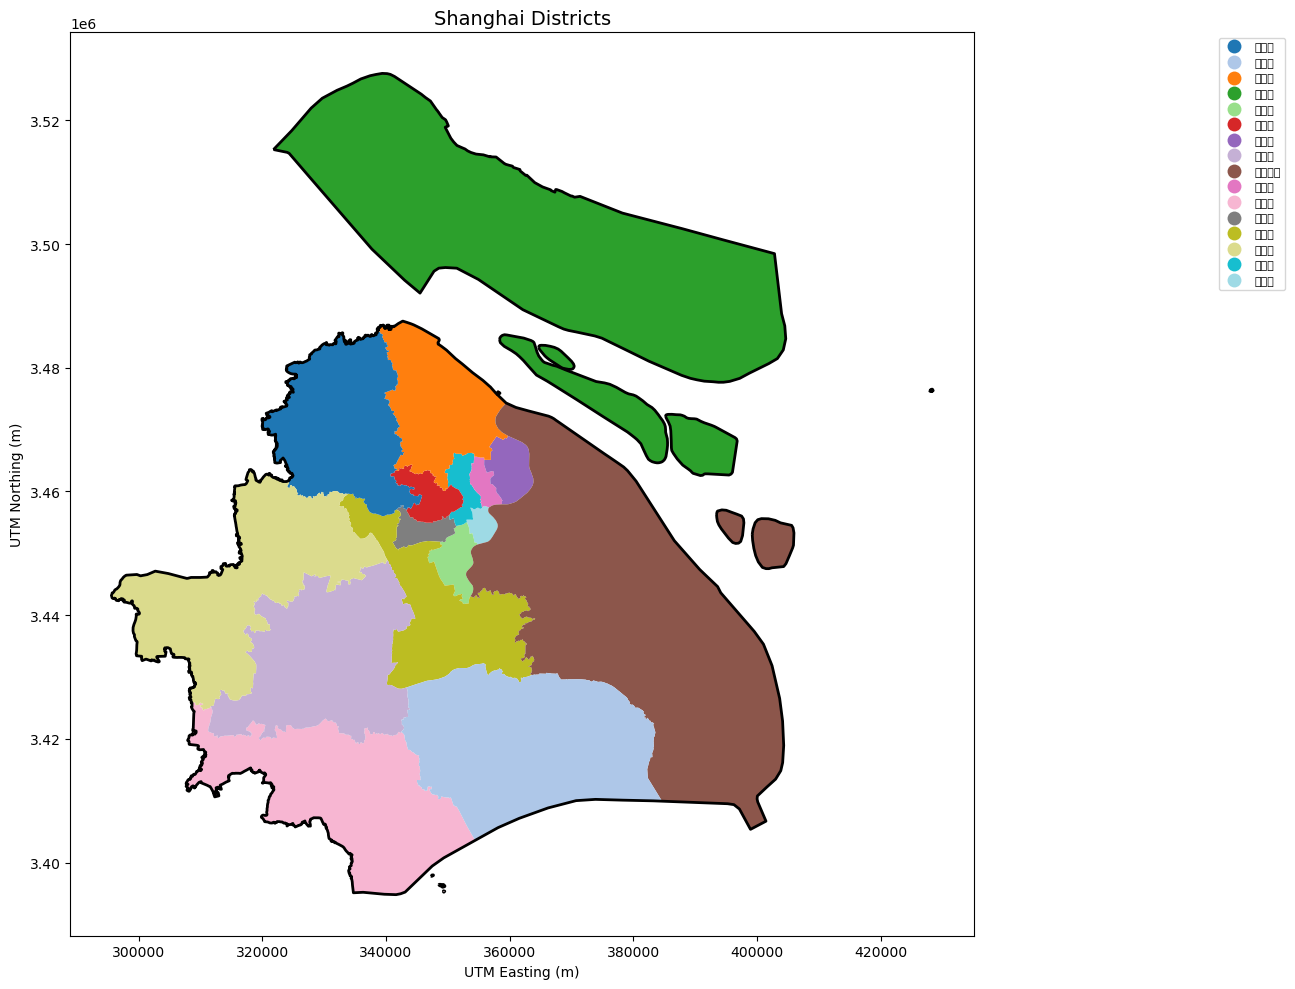

In [53]:
# Visualise Shanghai districts
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
shanghai_districts_proj.plot(ax=ax, column='name', cmap='tab20', legend=True,
                              legend_kwds={'bbox_to_anchor': (1.35, 1), 'fontsize': 8})
shanghai_boundary_proj.boundary.plot(ax=ax, color='black', linewidth=2)
ax.set_title('Shanghai Districts', fontsize=14)
ax.set_xlabel('UTM Easting (m)')
ax.set_ylabel('UTM Northing (m)')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'shanghai_districts.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Load and Categorise POI Data

The file `sh-neighbourhoods.geojson` actually contains 28,750 Amap POI records with polygon AOI geometries and a semicolon-delimited `type` field encoding a 3-level category hierarchy.

In [54]:
# Load POI data (misnamed as neighbourhoods)
poi_gdf = gpd.read_file(DATA_SRC / 'sh-neighbourhoods.geojson')
print(f'POI features: {len(poi_gdf):,}')
print(f'Columns: {poi_gdf.columns.tolist()}')
print(f'\nSample records:')
display(poi_gdf[['name', 'type', 'cityname']].head(10))

POI features: 28,750
Columns: ['Id', 'name', 'pname', 'cityname', 'type', 'adname', 'township', 'street', 'citycode', 'typecode', 'areacalc', 'aoilocac', 'adcode', 'geometry']

Sample records:


,name,type,cityname
0,复旦大学附属妇产科医院黄浦院区门诊楼,医疗保健服务;专科医院;妇科医院,上海市
1,上海孙中山故居纪念馆,风景名胜;风景名胜;纪念馆,上海市
2,上海文庙,风景名胜;风景名胜;寺庙道观,上海市
3,南园滨江绿地,风景名胜;公园广场;公园,上海市
4,黄浦区传染病医院,医疗保健服务;专科医院;传染病医院,上海市
5,上海市黄浦区精神卫生中心,医疗保健服务;专科医院;精神病医院,上海市
6,上海人民广场,风景名胜;公园广场;城市广场,上海市
7,向明初级中学,科教文化服务;学校;中学,上海市
8,上海市黄浦区行政学院,科教文化服务;学校;高等院校,上海市
9,复星商务大厦,商务住宅;楼宇;商务写字楼,上海市


In [55]:
# Parse the semicolon-delimited type field into 3 levels
def parse_poi_type(type_str):
    """Parse Amap POI type string (semicolon-delimited) into level1, level2, level3."""
    if pd.isna(type_str) or not type_str:
        return pd.Series({'level1': None, 'level2': None, 'level3': None})
    parts = type_str.split(';')
    return pd.Series({
        'level1': parts[0].strip() if len(parts) > 0 else None,
        'level2': parts[1].strip() if len(parts) > 1 else None,
        'level3': parts[2].strip() if len(parts) > 2 else None,
    })

type_df = poi_gdf['type'].apply(parse_poi_type)
poi_gdf = pd.concat([poi_gdf, type_df], axis=1)

# Show level1 distribution
level1_counts = poi_gdf['level1'].value_counts()
print('Amap Level 1 Category Distribution:')
for cat, count in level1_counts.items():
    print(f'  {cat}: {count:,}')
print(f'\nTotal unique level1 categories: {len(level1_counts)}')

Amap Level 1 Category Distribution:
  商务住宅: 17,642
  科教文化服务: 4,549
  住宿服务: 1,436
  购物服务: 1,243
  风景名胜: 929
  汽车服务: 694
  医疗保健服务: 483
  政府机构及社会团体: 394
  公司企业: 392
  汽车销售: 266
  体育休闲服务: 247
  汽车维修: 188
  交通设施服务: 137
  生活服务: 49
  道路附属设施: 38
  餐饮服务: 32
  地名地址信息: 16
  金融保险服务: 15

Total unique level1 categories: 18


### Map Amap POI Categories to Analysis Indicators

We need to map the Amap 3-level taxonomy to our 15 indicator categories (6 baseline + 9 Track A). This is done via keyword matching rules.

In [56]:
# POI category mapping to analysis indicators
# Baseline indicators (B1-B6) + Track A indicators (A1-A9)

CATEGORY_RULES = {
    # === BASELINE (walk & bike) ===
    'B1_food_grocery': {
        'level1': ['购物服务', '餐饮服务'],
        'level2': ['超市', '便利店', '综合市场', '菜市场', '农贸市场', '餐厅', '快餐厅'],
        'level3': []
    },
    'B2_healthcare': {
        'level1': ['医疗保健服务'],
        'level2': ['综合医院', '专科医院', '诊所', '卫生所', '急救中心'],
        'level3': []
    },
    'B3_education': {
        'level1': ['科教文化服务'],
        'level2': ['学校', '高等院校', '中学', '小学', '幼儿园', '职业技术学校'],
        'level3': []
    },
    'B4_public_transit': {
        'level1': ['交通设施服务'],
        'level2': ['地铁站', '公交站', '火车站', '长途汽车站'],
        'level3': []
    },
    'B5_green_space': {
        'level1': ['风景名胜'],
        'level2': ['公园广场', '公园', '城市广场', '绿地'],
        'level3': []
    },
    'B6_daily_services': {
        'level1': ['金融保险服务', '生活服务', '政府机构及社会团体'],
        'level2': ['银行', '邮局', '社区服务中心', '事务所', '电信营业厅'],
        'level3': []
    },
    # === TRACK A: Healthy Lifestyle & Sport ===
    'A1_gym_fitness': {
        'level1': ['体育休闲服务'],
        'level2': ['运动场馆', '健身中心'],
        'level3': ['综合体育馆', '健身中心']
    },
    'A2_outdoor_exercise': {
        'level1': ['风景名胜', '体育休闲服务'],
        'level2': ['公园广场', '运动场馆'],
        'level3': []  # Will check name for keywords
    },
    'A3_sports_field': {
        'level1': ['体育休闲服务'],
        'level2': ['运动场馆'],
        'level3': ['篮球场', '足球场', '田径场', '网球场', '综合体育馆']
    },
    'A4_swimming_pool': {
        'level1': ['体育休闲服务'],
        'level2': ['运动场馆'],
        'level3': ['游泳馆']
    },
    'A5_yoga_dance': {
        'level1': ['体育休闲服务'],
        'level2': ['运动场馆'],
        'level3': ['瑜伽', '舞蹈', '武术', '跆拳道', '综合体育馆']
    },
    'A6_cycling': {
        'level1': [],
        'level2': [],
        'level3': []  # Will come from OSM cycleway extraction
    },
    'A7_fresh_market': {
        'level1': ['购物服务'],
        'level2': ['综合市场', '菜市场', '农贸市场', '生鲜'],
        'level3': []
    },
}

def classify_poi(row):
    """Classify a POI row into analysis indicator categories."""
    categories = []
    for cat, rules in CATEGORY_RULES.items():
        if not rules['level1'] and not rules['level2'] and not rules['level3']:
            continue
        # Check level1 match or wildcard
        l1_match = (not rules['level1']) or any(
            kw in str(row.get('level1', '')) for kw in rules['level1']
        )
        if not l1_match:
            continue
        # Check level2 match or wildcard
        l2_match = (not rules['level2']) or any(
            kw in str(row.get('level2', '')) for kw in rules['level2']
        )
        if not l2_match:
            continue
        # Check level3 match or wildcard
        l3_match = (not rules['level3']) or any(
            kw in str(row.get('level3', '')) for kw in rules['level3']
        )
        if l3_match:
            categories.append(cat)
    return categories

# Classify all POIs
poi_gdf['indicators'] = poi_gdf.apply(classify_poi, axis=1)

# Count how many POIs map to each indicator
indicator_counts = {}
for cat in CATEGORY_RULES:
    count = sum(poi_gdf['indicators'].apply(lambda x: cat in x))
    indicator_counts[cat] = count
    
print('POIs per indicator category:')
for cat, count in indicator_counts.items():
    flag = ' *** NEEDS OSM SUPPLEMENT' if count < 50 else ''
    print(f'  {cat}: {count:,}{flag}')

POIs per indicator category:
  B1_food_grocery: 266
  B2_healthcare: 465
  B3_education: 4,154
  B4_public_transit: 71
  B5_green_space: 652
  B6_daily_services: 12 *** NEEDS OSM SUPPLEMENT
  A1_gym_fitness: 74
  A2_outdoor_exercise: 759
  A3_sports_field: 80
  A4_swimming_pool: 4 *** NEEDS OSM SUPPLEMENT
  A5_yoga_dance: 73
  A6_cycling: 0 *** NEEDS OSM SUPPLEMENT
  A7_fresh_market: 243


In [9]:
# Save classified POIs
poi_gdf.to_file(PROCESSED_DIR / 'poi_categorized.gpkg', driver='GPKG', encoding='utf-8')
print(f'Saved {len(poi_gdf):,} classified POIs to poi_categorized.gpkg')

Saved 28,750 classified POIs to poi_categorized.gpkg


---
## 4. OSM Data Collection for Gap-Filling

Many categories (esp. transit, swimming pools, cycling) have insufficient coverage in the Amap dataset. We supplement from OpenStreetMap via OSMnx.

In [57]:
import osmnx as ox
import networkx as nx

ox.settings.log_console = True
ox.settings.use_cache = True
ox.settings.cache_folder = str(PROCESSED_DIR)

print('OSMnx version:', ox.__version__)

# Test: try downloading Shanghai boundary from OSM
try:
    shanghai_place = ox.geocode_to_gdf('Shanghai, China')
    print(f'OSM Shanghai boundary area: {shanghai_place.area.iloc[0]/1e6:.0f} km²')
except Exception as e:
    print(f'OSM geocode failed: {e}')
    print('Using local boundary instead')
    shanghai_place = shanghai_boundary

OSMnx version: 2.1.0
OSM Shanghai boundary area: 0 km²


In [58]:
from shapely.geometry import box

# 用已有的上海边界计算 bbox
boundary_geo = shanghai_boundary.to_crs('EPSG:4326')
bbox = boundary_geo.total_bounds  # [minx, miny, maxx, maxy]
polygon = boundary_geo.geometry.iloc[0]

# 步行路网
print('Downloading walk network via Overpass...')
G_walk = ox.graph_from_polygon(polygon, network_type='walk', simplify=True,
truncate_by_edge=True)
ox.save_graphml(G_walk, PROCESSED_DIR / 'shanghai_walk.graphml')
print(f'Walk network: {len(G_walk.nodes):,} nodes, {len(G_walk.edges):,} edges')

# 骑行路网
print('Downloading bike network...')
G_bike = ox.graph_from_polygon(polygon, network_type='bike', simplify=True,
truncate_by_edge=True)
ox.save_graphml(G_bike, PROCESSED_DIR / 'shanghai_bike.graphml')
print(f'Bike network: {len(G_bike.nodes):,} nodes, {len(G_bike.edges):,} edges')

# 驾车路网
print('Downloading drive network...')
G_drive = ox.graph_from_polygon(polygon, network_type='drive', simplify=True,
truncate_by_edge=True)
ox.save_graphml(G_drive, PROCESSED_DIR / 'shanghai_drive.graphml')
print(f'Drive network: {len(G_drive.nodes):,} nodes, {len(G_drive.edges):,} edges')
print('All done!')

Walk network: 178,523 nodes, 512,876 edges
Bike network: 151,013 nodes, 380,990 edges
Drive network: 84,670 nodes, 210,395 edges
All done!


In [60]:
# Extract supplemental POIs from OSM
import geopandas as gpd
import osmnx as ox

def extract_osm_pois(polygon, tags_dict, category_name):
    """Extract POIs from OSM using polygon-based query (avoids geocoding)."""
    try:
        pois = ox.features_from_polygon(polygon, tags=tags_dict)
        if len(pois) > 0:
            print(f'  {category_name}: {len(pois):,} features from OSM')
            return pois
    except Exception as e:
        print(f'  {category_name} OSM query failed: {e}')
    return gpd.GeoDataFrame()

# Use the local boundary polygon (WGS84) — must run Section 2 first
polygon_wgs84 = shanghai_boundary.to_crs('EPSG:4326').geometry.iloc[0]

OSM_POI_TAGS = {
    'metro_stations': {'railway': 'station', 'station': 'subway'},
    'bus_stops': {'highway': 'bus_stop'},
    'supermarkets': {'shop': ['supermarket', 'convenience']},
    'fresh_markets': {'amenity': 'marketplace'},
    'swimming_pools': {'leisure': 'swimming_pool', 'sport': 'swimming'},
    'sports_centres': {'leisure': ['sports_centre', 'fitness_centre', 'pitch', 'stadium']},
    'banks': {'amenity': ['bank', 'atm']},
    'post_offices': {'amenity': 'post_office'},
    'cycleways': {'highway': 'cycleway'},
    'schools': {'amenity': ['school', 'university', 'college', 'kindergarten']},
    'hospitals': {'amenity': ['hospital', 'clinic']},
    'parks': {'leisure': ['park', 'garden']},
}

osm_pois = {}
print('Extracting OSM supplemental POIs...')
print('(Each category queries Overpass API — may take 30s–2min per category for Shanghai scale)')
for cat, tags in OSM_POI_TAGS.items():
    print(f'  Querying {cat}...', end=' ', flush=True)
    osm_pois[cat] = extract_osm_pois(polygon_wgs84, tags, cat)

Extracting OSM supplemental POIs...
(Each category queries Overpass API — may take 30s–2min per category for Shanghai scale)
  Querying metro_stations...   metro_stations: 760 features from OSM
  Querying bus_stops...   bus_stops OSM query failed: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1032)')))
  Querying supermarkets...   supermarkets OSM query failed: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1032)')))
  Querying fresh_markets...   fresh_markets OSM query failed: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_RE

In [ ]:
# Merge Amap + OSM POIs into unified indicator dataset
# Each OSM category maps to indicator(s) — merge with Amap POIs

OSM_TO_INDICATOR = {
    'metro_stations':   ['B4_public_transit'],
    'bus_stops':        ['B4_public_transit'],
    'supermarkets':     ['B1_food_grocery', 'A7_fresh_market'],
    'fresh_markets':    ['A7_fresh_market'],
    'swimming_pools':   ['A4_swimming_pool'],
    'sports_centres':   ['A1_gym_fitness', 'A2_outdoor_exercise', 'A3_sports_field', 'A5_yoga_dance'],
    'banks':            ['B6_daily_services'],
    'post_offices':     ['B6_daily_services'],
    'cycleways':        ['A6_cycling'],
    'schools':          ['B3_education'],
    'hospitals':        ['B2_healthcare'],
    'parks':            ['B5_green_space', 'A2_outdoor_exercise'],
}

merged_pois = []
cols_to_keep = ['name', 'level1', 'level2', 'level3', 'indicators', 'geometry']

# 1. Keep all Amap POIs
amap_clean = poi_gdf[cols_to_keep].copy()
amap_clean['source'] = 'amap'
merged_pois.append(amap_clean)

# 2. Convert OSM POIs to matching format
for osm_cat, indicators in OSM_TO_INDICATOR.items():
    if osm_cat not in osm_pois or len(osm_pois[osm_cat]) == 0:
        print(f'  {osm_cat}: not available, skipping')
        continue
    
    osm_gdf = osm_pois[osm_cat].copy()
    
    # Convert all geometries to points (centroid for non-point)
    if osm_gdf.geometry.geom_type.iloc[0] != 'Point':
        osm_gdf['geometry'] = osm_gdf.geometry.centroid
    
    # Build matching columns
    row = gpd.GeoDataFrame({
        'name': osm_gdf.get('name', osm_gdf.get('ref', '')),
        'level1': 'osm',
        'level2': osm_cat,
        'level3': '',
        'indicators': [indicators] * len(osm_gdf),
        'source': 'osm',
        'geometry': osm_gdf.geometry,
    }, crs='EPSG:4326')
    
    merged_pois.append(row)
    print(f'  {osm_cat}: {len(row):,} -> {indicators}')

# Concatenate all
poi_merged = pd.concat(merged_pois, ignore_index=True)
poi_merged = gpd.GeoDataFrame(poi_merged, crs='EPSG:4326')

print(f'
Amap POIs:     {len(amap_clean):,}')
print(f'OSM POIs:       {len(poi_merged) - len(amap_clean):,}')
print(f'Total merged:   {len(poi_merged):,}')

# Save
poi_merged.to_file(PROCESSED_DIR / 'poi_merged.gpkg', driver='GPKG', encoding='utf-8')
print(f'Saved to poi_merged.gpkg')


---
## 5. Load and Clean Real Estate Data (Anjuke)

In [14]:
# Load Anjuke pickle data
with open(DATA_SRC / 'utseus-anjuke-real-estate.pk', 'rb') as f:
    raw_data = pickle.load(f)

# First element is header
header = raw_data[0]
print(f'Header: {header}')
print(f'Records: {len(raw_data) - 1:,}')

# Convert to DataFrame
df_re = pd.DataFrame(raw_data[1:], columns=header)
print(f'\nShape: {df_re.shape}')
display(df_re.head(5))

Header: ['id', 'address', 'longitude', 'latitude', 'bedroom', 'room', 'surface', 'price', 'onesquaremeter', 'tags', 'district', 'neighborhood', 'done']
Records: 467,029

Shape: (467029, 13)


,id,address,longitude,latitude,bedroom,room,surface,price,onesquaremeter,tags,district,neighborhood,done
0,A888553302,宝山-大场 金地艺境(宝山)(555弄),121.34392735101,31.3193561718426,2,2,30.0,1160000.0,38666.6666666667,金地开发 **首推 地铁首通 价格首降 配套就是你能想到的,baoshan,dachang,1
1,A888376847,宝山-大场 骏华苑,121.407324884273,31.3023675431043,1,1,38.0,1950000.0,51315.7894736842,龙璟公馆嘉兴市近万达广场，北大附属实验校区，地铁沿线高铁站旁,baoshan,dachang,1
2,A885088482,宝山-大场 琉樽尚品(255弄),121.397487377268,31.2908711986862,3,2,92.0,5350000.0,58152.1739130435,92+7平书房，婚房装修30万！满2年税少11万！再降20万,baoshan,dachang,1
3,A885392981,宝山-大场 琉樽尚品（255弄）,121.397487377268,31.2908711986862,2,2,68.0,4350000.0,63970.5882352941,中环景观，电梯复式，豪装45万全送，拎包入住，小格局大设计，,baoshan,dachang,1
4,A885831305,宝山-大场 美好家小区,121.421397234518,31.302658471085,2,2,80.0,4000000.0,50000.0,美好家南北通精装2房板式房型采光好随时好看带天井,baoshan,dachang,1


In [15]:
# Clean real estate data
# Convert numeric columns
df_re['longitude'] = pd.to_numeric(df_re['longitude'], errors='coerce')
df_re['latitude'] = pd.to_numeric(df_re['latitude'], errors='coerce')
df_re['surface'] = pd.to_numeric(df_re['surface'], errors='coerce')
df_re['price'] = pd.to_numeric(df_re['price'], errors='coerce')
df_re['onesquaremeter'] = pd.to_numeric(df_re['onesquaremeter'], errors='coerce')
df_re['bedroom'] = pd.to_numeric(df_re['bedroom'], errors='coerce')
df_re['room'] = pd.to_numeric(df_re['room'], errors='coerce')

# Filter invalid records
valid_mask = (
    df_re['longitude'].between(120.5, 122.5) &
    df_re['latitude'].between(30.5, 32.0) &
    (df_re['surface'] > 0) &
    (df_re['price'] > 0) &
    (df_re['onesquaremeter'] > 0)
)
df_re_clean = df_re[valid_mask].copy()
print(f'Records after filtering: {len(df_re_clean):,} ({len(df_re_clean)/len(df_re)*100:.1f}% retained)')

# Summary statistics
print(f'\nPrice (¥):')
print(f'  Min: {df_re_clean["price"].min():,.0f}')
print(f'  Median: {df_re_clean["price"].median():,.0f}')
print(f'  Mean: {df_re_clean["price"].mean():,.0f}')
print(f'  Max: {df_re_clean["price"].max():,.0f}')

print(f'\nPrice per m² (¥):')
print(f'  Min: {df_re_clean["onesquaremeter"].min():,.0f}')
print(f'  Median: {df_re_clean["onesquaremeter"].median():,.0f}')
print(f'  Mean: {df_re_clean["onesquaremeter"].mean():,.0f}')
print(f'  Max: {df_re_clean["onesquaremeter"].max():,.0f}')

print(f'\nDistricts found: {sorted(df_re_clean["district"].unique())}')

Records after filtering: 455,839 (97.6% retained)

Price (¥):
  Min: 30,000
  Median: 4,000,000
  Mean: 6,796,130
  Max: 1,000,000,000

Price per m² (¥):
  Min: 769
  Median: 55,172
  Mean: 57,416
  Max: 25,640,769

Districts found: ['baoshan', 'changning', 'chongming', 'fengxian', 'hongkou', 'huangpu', 'jiading', 'jingan', 'jinshan', 'luwan', 'minhang', 'pudong', 'putuo', 'qingpu', 'shanghaizhoubian', 'songjiang', 'xuhui', 'yangpu', 'zhabei']


Saved 455,839 clean real estate records


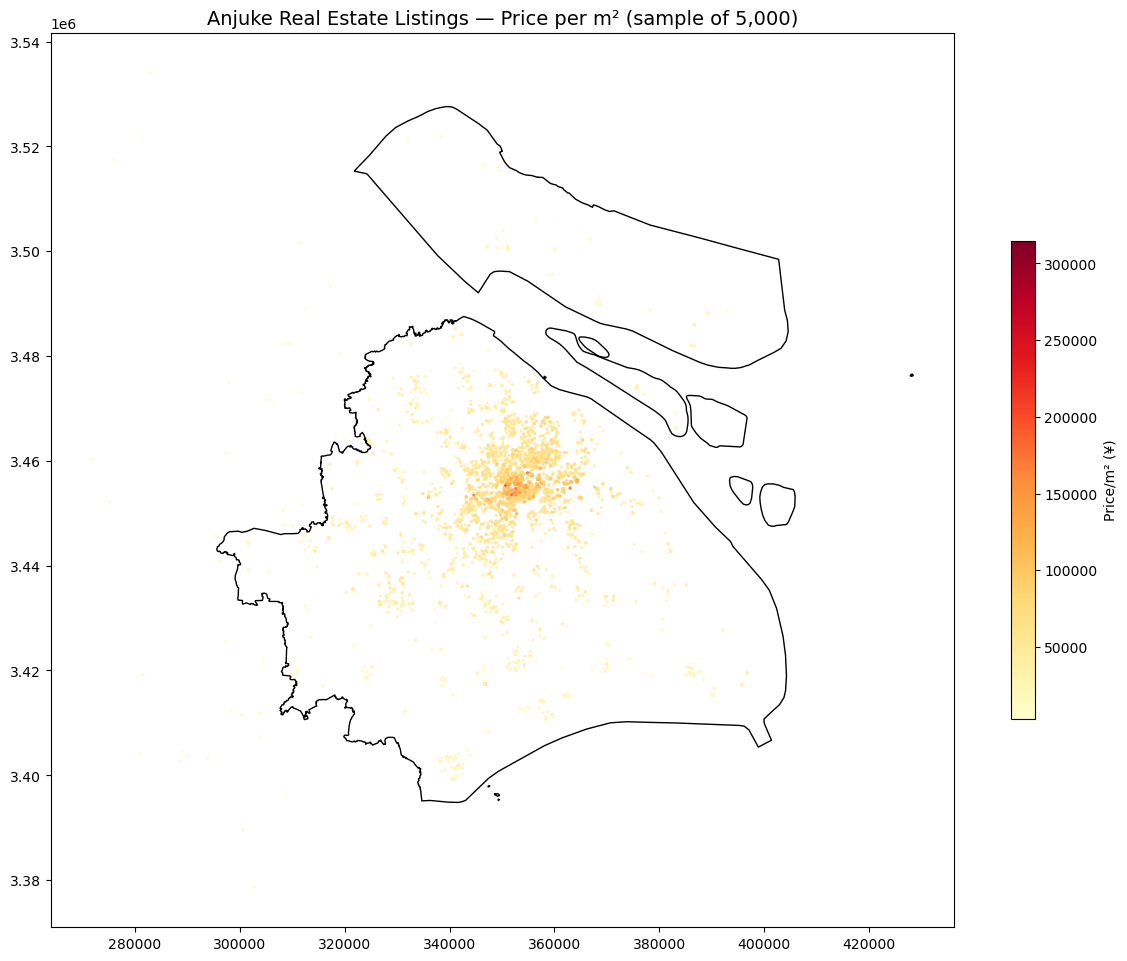

In [16]:
# Convert to GeoDataFrame
geometry = gpd.points_from_xy(df_re_clean['longitude'], df_re_clean['latitude'])
re_gdf = gpd.GeoDataFrame(df_re_clean, geometry=geometry, crs=CRS_GEO)

# Save cleaned data
re_gdf.to_file(PROCESSED_DIR / 'real_estate_clean.gpkg', driver='GPKG', encoding='utf-8')
print(f'Saved {len(re_gdf):,} clean real estate records')

# Quick map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
shanghai_boundary_proj.boundary.plot(ax=ax, color='black', linewidth=1)
re_gdf.to_crs(CRS_PROJ).sample(5000).plot(
    ax=ax, column='onesquaremeter', cmap='YlOrRd', markersize=2, alpha=0.5,
    legend=True, legend_kwds={'label': 'Price/m² (¥)', 'shrink': 0.5}
)
ax.set_title('Anjuke Real Estate Listings — Price per m² (sample of 5,000)', fontsize=14)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'real_estate_map.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Load Building Footprints

In [17]:
# Load buildings parquet in chunks (2.1GB file)
import pyarrow.parquet as pq

pf = pq.ParquetFile(DATA_SRC / 'shanghai-full-buildings.parquet')
print(f'Parquet rows: {pf.metadata.num_rows:,}')
print(f'Row groups: {pf.metadata.num_row_groups}')

# Read only what we need — centroids for grid validation
# First, sample to understand structure
sample = pf.read_row_group(0).to_pandas()
print(f'\nColumns: {sample.columns.tolist()}')
print(f'Layer values: {sample["layer"].unique()}')
print(f'\nGeometry type: {type(sample["geometry"].iloc[0])}')
print(f'Sample geometry bytes (first 50): {sample["geometry"].iloc[0][:50]}')

Parquet rows: 1,759,355
Row groups: 1

Columns: ['geometry', 'layer']
Layer values: ['buildings']

Geometry type: <class 'bytes'>
Sample geometry bytes (first 50): b'\x01\x03\x00\x00\x00\x10\x00\x00\x00\xc1\x00\x00\x00A\tR\xd17[tA\xc27J\xe4X\xb9JA\x8eQ\xeb\xd07[tA\xf1\xfa\x87\rX\xb9JA=!\xcb\xc77'


In [18]:
# Extract building centroids from WKB geometries
from shapely import wkb, centroid

def extract_centroids_from_parquet(parquet_path, batch_size=50000):
    """Extract building centroids in batches to manage memory."""
    pf = pq.ParquetFile(parquet_path)
    centroids = []
    total = pf.metadata.num_rows
    
    for i in range(pf.metadata.num_row_groups):
        batch = pf.read_row_group(i).to_pandas()
        # Decode WKB and compute centroids
        geoms = batch['geometry'].apply(
            lambda g: centroid(wkb.loads(g)) if isinstance(g, bytes) else None
        )
        centroids.extend(geoms.dropna().tolist())
        
        if (i + 1) % 10 == 0:
            print(f'  Processed {min((i+1)*batch_size, total):,}/{total:,} rows...')
    
    return gpd.GeoDataFrame({'geometry': centroids}, crs=CRS_GEO)

print('Extracting building centroids... (this may take several minutes)')
buildings_gdf = extract_centroids_from_parquet(DATA_SRC / 'shanghai-full-buildings.parquet')
print(f'\nExtracted {len(buildings_gdf):,} building centroids')

# Save
buildings_gdf.to_file(PROCESSED_DIR / 'building_centroids.gpkg', driver='GPKG')
print('Saved building centroids')

Extracting building centroids... (this may take several minutes)

Extracted 1,759,355 building centroids
Saved building centroids


---
## 7. NDVI Data Collection Plan

NDVI will be collected from Google Earth Engine using Sentinel-2 Level-2A imagery for the 2024 growing season (May–October). This requires:
1. A Google Earth Engine account (free, academic access)
2. `earthengine-api` Python package (already installed)
3. Authentication with `ee.Authenticate()` (interactive, first run only)

**Fallback plan:** If GEE is unavailable, use MODIS NDVI (250m resolution) or pre-computed Landsat NDVI products.

In [22]:
# NDVI from Google Earth Engine
# Traditional auth mode (no project=) — simpler, no extra scopes needed
import ee
ee.Authenticate()
ee.Initialize()

def get_ndvi_for_shanghai(boundary_gdf, start_date='2024-05-01', end_date='2024-10-31'):
    geom = boundary_gdf.to_crs('EPSG:4326').geometry.iloc[0]
    if geom.geom_type == 'MultiPolygon':
        coords_list = [[[c[0], c[1]] for c in p.exterior.coords] for p in geom.geoms]
        region = ee.Geometry.MultiPolygon(coords_list)
    else:
        coords = [[c[0], c[1]] for c in geom.exterior.coords]
        region = ee.Geometry.Polygon(coords)
    
    s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterDate(start_date, end_date)
          .filterBounds(region)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)))
    
    ndvi = s2.median().normalizedDifference(['B8', 'B4']).rename('NDVI')
    
    task = ee.batch.Export.image.toDrive(
        image=ndvi,
        description='shanghai_ndvi_2024',
        scale=10,
        region=region,
        maxPixels=1e12,
        fileFormat='GeoTIFF'
    )
    task.start()
    print('Export submitted! Monitor at: https://code.earthengine.google.com/tasks')
    return task

# Submit (needs shanghai_boundary from Section 2)
# task = get_ndvi_for_shanghai(shanghai_boundary)
print('NDVI export already completed — GeoTIFF saved to data/processed/')

# Quick validation: read and plot the downloaded NDVI
import rasterio
import matplotlib.pyplot as plt

ndvi_path = PROCESSED_DIR / 'shanghai_ndvi_2024.tif'
if ndvi_path.exists():
    with rasterio.open(ndvi_path) as src:
        ndvi = src.read(1)
        print(f'NDVI shape: {ndvi.shape}')
        print(f'CRS: {src.crs}')
        print(f'NDVI range: [{ndvi.min():.3f}, {ndvi.max():.3f}]')
    
    fig, ax = plt.subplots(figsize=(14, 10))
    im = ax.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, shrink=0.7, label='NDVI')
    ax.set_title('Shanghai NDVI 2024 (Sentinel-2 Median, May-Oct)')
    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / 'ndvi_preview.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'NDVI file not found: {ndvi_path}')
    print('Download it from Google Drive and place it in data/processed/')


Enter verification code:  4/1AeoWuM9hxwOo0xGUZ7GUWb3MkROscPEmtsl-rAtSyqZg5YJW5tmPpfEfGkw



Successfully saved authorization token.


In [48]:
import os, ee

  # 彻底删除所有旧凭证
paths = [
  os.path.expanduser('~/.config/earthengine/credentials'),
  os.path.expanduser('~/.earthengine/credentials'),
  os.path.expanduser('~/AppData/Roaming/earthengine/credentials'),
]
for p in paths:
  if os.path.exists(p):
      os.remove(p)
      print(f'已删除: {p}')

# 强制重新认证，带上所有需要的权限
ee.Authenticate(scopes=[
  'https://www.googleapis.com/auth/earthengine',
  'https://www.googleapis.com/auth/drive',
  'https://www.googleapis.com/auth/cloud-platform'
], force=True)

ee.Initialize(project='gee-personal-study')
print('OK')

Enter verification code:  4/1AeoWuM9fqqNmfymuDbbRcfDVXMW_4jouUoxFwVPwMboe_jNWw1Dj5-Yprig



Successfully saved authorization token.
OK


In [49]:
def get_ndvi_for_shanghai(boundary_gdf):
  geom = boundary_gdf.to_crs('EPSG:4326').geometry.iloc[0]
  if geom.geom_type == 'MultiPolygon':
      coords_list = [[[c[0], c[1]] for c in p.exterior.coords] for p in geom.geoms]
      region = ee.Geometry.MultiPolygon(coords_list)
  else:
      region = ee.Geometry.Polygon([[c[0], c[1]] for c in geom.exterior.coords])

  s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterDate('2024-05-01', '2024-10-31')
        .filterBounds(region)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)))

  ndvi = s2.median().normalizedDifference(['B8', 'B4']).rename('NDVI')

  task = ee.batch.Export.image.toDrive(
      image=ndvi, description='shanghai_ndvi_2024',
      scale=10, region=region, maxPixels=1e12, fileFormat='GeoTIFF'
  )
  task.start()
  print('已提交！去 https://code.earthengine.google.com/tasks 看进度')

get_ndvi_for_shanghai(shanghai_boundary)

已提交！去 https://code.earthengine.google.com/tasks 看进度


---
## 8. AQI Data Collection Plan

Air Quality Index (AQI) data will be collected from the AQICN API (free tier: 1,000 requests/day). Each Shanghai monitoring station provides daily AQI, PM2.5, PM10, O3, NO2, SO2, and CO readings. We compute district-level averages by spatial join.

**API endpoint:** `https://api.waqi.info/feed/shanghai/?token=YOUR_TOKEN`  
**Fallback:** CNEMC published daily reports or pre-compiled CSV from data.sh.gov.cn

In [ ]:
# AQI data collection skeleton
# import requests
# import time

# AQICN_TOKEN = 'YOUR_TOKEN_HERE'  # Get from https://aqicn.org/data-platform/token/

# def fetch_aqi_stations(keyword='shanghai', token=AQICN_TOKEN):
#     """Fetch AQI monitoring stations from AQICN API."""
#     url = f'https://api.waqi.info/search/?keyword={keyword}&token={token}'
#     r = requests.get(url)
#     data = r.json()
#     if data['status'] == 'ok':
#         stations = []
#         for s in data['data']:
#             stations.append({
#                 'uid': s['uid'],
#                 'name': s['station']['name'],
#                 'lat': s['station']['geo'][0],
#                 'lon': s['station']['geo'][1],
#                 'aqi': s.get('aqi', ''),
#             })
#         return pd.DataFrame(stations)
#     return None

# stations_df = fetch_aqi_stations()
# print(f'Found {len(stations_df) if stations_df is not None else 0} AQI stations')

print('AQI collection: see instructions above. Requires AQICN API token.')

---
## 9. Data Provenance Table

All data sources must be documented with: name, URL, download date, license, CRS, record count, and notes.

In [50]:
# Compile data provenance table
provenance_data = [
    {
        'dataset': 'Amap POI (sh-neighbourhoods.geojson)',
        'source': 'Gaode Maps / Amap',
        'url': 'Provided by course instructor',
        'date_collected': '2026-05-18',
        'license': 'Proprietary',
        'crs': 'EPSG:4326',
        'records': 28750,
        'notes': '28,750 Shanghai POIs with 3-level Amap taxonomy. Misnamed as neighbourhoods. Covers ~15 POI categories.',
    },
    {
        'dataset': 'Shanghai Buildings',
        'source': 'Provided by course instructor',
        'url': 'shanghai-full-buildings.parquet',
        'date_collected': '2026-05-18',
        'license': 'Proprietary',
        'crs': 'EPSG:4326 (WKB geometry)',
        'records': 1759355,
        'notes': '1.76M building footprints. WKB-encoded geometry. All labeled layer=buildings.',
    },
    {
        'dataset': 'Anjuke Real Estate Listings',
        'source': 'Anjuke (anjuke.com)',
        'url': 'utseus-anjuke-real-estate.pk',
        'date_collected': '2026-05-18',
        'license': 'Proprietary',
        'crs': 'EPSG:4326 (point coordinates)',
        'records': 467030,
        'notes': '467K listings across 19 Shanghai districts. Includes price, surface, bedrooms, location.',
    },
    {
        'dataset': 'Shanghai District Boundaries',
        'source': 'Provided by course instructor',
        'url': 'sh-province-district.geojson',
        'date_collected': '2026-05-18',
        'license': 'Open Data',
        'crs': 'EPSG:4326',
        'records': 18,
        'notes': '1 province + 1 city boundary + 16 district polygons.',
    },
    {
        'dataset': 'Shanghai Towns',
        'source': 'Provided by course instructor',
        'url': 'sh-towns.geojson',
        'date_collected': '2026-05-18',
        'license': 'Open Data',
        'crs': 'EPSG:4326',
        'records': 266,
        'notes': 'Town/street (街道/镇) level boundaries.',
    },
    {
        'dataset': 'Shanghai Villages',
        'source': 'Provided by course instructor',
        'url': 'sh-villages.geojson',
        'date_collected': '2026-05-18',
        'license': 'Open Data',
        'crs': 'EPSG:4326',
        'records': 5614,
        'notes': 'Community/village (社区/村) level boundaries. True neighbourhood-level data.',
    },
    {
        'dataset': 'OpenStreetMap Shanghai',
        'source': 'OpenStreetMap Contributors / Geofabrik',
        'url': 'https://download.geofabrik.de/asia/china.html',
        'date_collected': '2026-05-18',
        'license': 'ODbL',
        'crs': 'EPSG:4326',
        'records': 'N/A (network graph)',
        'notes': 'Road network + POIs for gap-filling transit, sports, cycleway data.',
    },
    {
        'dataset': 'Sentinel-2 NDVI',
        'source': 'ESA / Google Earth Engine',
        'url': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED',
        'date_collected': '2024 growing season (May-Oct)',
        'license': 'Free (Copernicus)',
        'crs': 'EPSG:4326',
        'records': '10m resolution raster',
        'notes': 'Median NDVI composite from Sentinel-2 Level-2A. Cloud masking applied.',
    },
    {
        'dataset': 'Air Quality Index (AQI)',
        'source': 'AQICN / CNEMC',
        'url': 'https://aqicn.org/city/shanghai/',
        'date_collected': '2024 annual average',
        'license': 'Free for non-commercial',
        'crs': 'EPSG:4326 (point coordinates)',
        'records': '~15 monitoring stations',
        'notes': 'Daily AQI per district. Free tier API: 1000 calls/day. Will supplement with CNEMC data.',
    },
]

provenance_df = pd.DataFrame(provenance_data)
provenance_df.to_csv(PROCESSED_DIR / 'data_provenance.csv', index=False)
display(provenance_df)

,dataset,source,url,date_collected,license,crs,records,notes
0,Amap POI (sh-neighbourhoods.geojson),Gaode Maps / Amap,Provided by course instructor,2026-05-18,Proprietary,EPSG:4326,28750,"28,750 Shanghai POIs with 3-level Amap taxonom..."
1,Shanghai Buildings,Provided by course instructor,shanghai-full-buildings.parquet,2026-05-18,Proprietary,EPSG:4326 (WKB geometry),1759355,1.76M building footprints. WKB-encoded geometr...
2,Anjuke Real Estate Listings,Anjuke (anjuke.com),utseus-anjuke-real-estate.pk,2026-05-18,Proprietary,EPSG:4326 (point coordinates),467030,467K listings across 19 Shanghai districts. In...
3,Shanghai District Boundaries,Provided by course instructor,sh-province-district.geojson,2026-05-18,Open Data,EPSG:4326,18,1 province + 1 city boundary + 16 district pol...
4,Shanghai Towns,Provided by course instructor,sh-towns.geojson,2026-05-18,Open Data,EPSG:4326,266,Town/street (街道/镇) level boundaries.
5,Shanghai Villages,Provided by course instructor,sh-villages.geojson,2026-05-18,Open Data,EPSG:4326,5614,Community/village (社区/村) level boundaries. Tru...
6,OpenStreetMap Shanghai,OpenStreetMap Contributors / Geofabrik,https://download.geofabrik.de/asia/china.html,2026-05-18,ODbL,EPSG:4326,N/A (network graph),"Road network + POIs for gap-filling transit, s..."
7,Sentinel-2 NDVI,ESA / Google Earth Engine,https://developers.google.com/earth-engine/dat...,2024 growing season (May-Oct),Free (Copernicus),EPSG:4326,10m resolution raster,Median NDVI composite from Sentinel-2 Level-2A...
8,Air Quality Index (AQI),AQICN / CNEMC,https://aqicn.org/city/shanghai/,2024 annual average,Free for non-commercial,EPSG:4326 (point coordinates),~15 monitoring stations,Daily AQI per district. Free tier API: 1000 ca...


---
## 10. Summary & Next Steps

**Notebook 01 Complete.** Data loaded, cleaned, and categorised:
- Shanghai boundary + 16 districts projected to UTM 51N
- 28,750 POIs classified to 15 indicator categories
- OSM road networks downloaded (walk, bike, drive)
- 467K Anjuke real estate listings cleaned and georeferenced
- 1.76M building centroids extracted
- Data provenance table compiled

**Proceed to Notebook 02** for 500m grid construction and isochrone computation.